In [1]:
# Author: Arthur Prigent
# Email: arthur.prigent@univ-brest.fr

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import datetime as dt
import gsw
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import ArcTools as Atools
import pandas as pd

# Vertical grid from ISAS

In [3]:
# read
dir_clim = '/data0/user/aprigent/ISAS/ISAS17_Mask.nc'
mask = xr.open_dataset(dir_clim)
zi = mask.depthCFD.data


# Vertical interpolation function

In [4]:
def interp_prof(x_old, y_old, x_new):

    # Import interpolation methods from SciPy
    # (only Akima1DInterpolator is actually used below)
    from scipy.interpolate import Akima1DInterpolator
    
    yi = []   # list to store interpolated profiles
    iyi = []  # list to store indices of successfully interpolated profiles
    
    # Loop over each profile (rows of y_old)
    for i in range(0, y_old.shape[0]):
        
        # Extract the i-th profile
        y = y_old[i, :]
        x = x_old[i, :]
        
        # Identify non-NaN values in y and x_old
        inans_y = ~np.isnan(y)
        inans_x = ~np.isnan(x)
       
        # print(len(inans_x),len(inans_y))
        # Keep only points where both x and y are valid
        inans = inans_y * inans_x
        
        
        # Proceed only if there are any valid points
        if np.any(inans):
            
            # Need at least 2 valid points for interpolation
            if len(y[inans]) > 1:
                # print(i)

                # Create Akima spline interpolator using valid data points
                try :
                    spl = Akima1DInterpolator(x[inans], y[inans])
                
                
                    # Interpolate profile onto the new x grid
                    prof = spl(x_new)
                
                    # Store interpolated profile and its original index
                    yi.append(prof)
                    iyi.append(i)
                except ValueError:
                    continue
                
    # Return:
    # - array of interpolated profiles
    # - array of indices of profiles that were successfully interpolated
    return np.array(yi), np.array(iyi)


### List ARGO profiles

In [5]:
argo_path = '/data0/user/aprigent/ARGO/Arctic/'
interpolated_trajectories_argo = [6903119, 6903143,6903144,6903145,6903146,
                                  6903147,7901038,3902112,3902118,4903655,
                                  6903587,6903588,6903589,6904087,7900549,7902188]
list_file = [argo_path+str(id_argo)+'_prof.nc' for id_argo in interpolated_trajectories_argo]
list_file

['/data0/user/aprigent/ARGO/Arctic/6903119_prof.nc',
 '/data0/user/aprigent/ARGO/Arctic/6903143_prof.nc',
 '/data0/user/aprigent/ARGO/Arctic/6903144_prof.nc',
 '/data0/user/aprigent/ARGO/Arctic/6903145_prof.nc',
 '/data0/user/aprigent/ARGO/Arctic/6903146_prof.nc',
 '/data0/user/aprigent/ARGO/Arctic/6903147_prof.nc',
 '/data0/user/aprigent/ARGO/Arctic/7901038_prof.nc',
 '/data0/user/aprigent/ARGO/Arctic/3902112_prof.nc',
 '/data0/user/aprigent/ARGO/Arctic/3902118_prof.nc',
 '/data0/user/aprigent/ARGO/Arctic/4903655_prof.nc',
 '/data0/user/aprigent/ARGO/Arctic/6903587_prof.nc',
 '/data0/user/aprigent/ARGO/Arctic/6903588_prof.nc',
 '/data0/user/aprigent/ARGO/Arctic/6903589_prof.nc',
 '/data0/user/aprigent/ARGO/Arctic/6904087_prof.nc',
 '/data0/user/aprigent/ARGO/Arctic/7900549_prof.nc',
 '/data0/user/aprigent/ARGO/Arctic/7902188_prof.nc']

In [6]:
def plot_trajectories(lon1,lat1,lon2,lat2):
    f,ax = plt.subplots(1,1,figsize=[10,10],subplot_kw={'projection': ccrs.NorthPolarStereo()})

    ftz=15

    Atools.plot_arctic_ax_map_new(ax)

    ax.scatter(lon1,
               lat1,
               marker='.',transform=ccrs.PlateCarree(),s=2,color='green',label='All',alpha=1)
    ax.scatter(lon2,
               lat2,
               marker='.',transform=ccrs.PlateCarree(),s=2,color='red',label='All',alpha=1)
    plt.show()
    

# Start looping on ARGO individual files

---------
    
/data0/user/aprigent/ARGO/Arctic/6903119_prof.nc
Correcting lon/lat


/tmp/ipykernel_1753263/2069012634.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv('/data0/user/aprigent/ARGO/estimate_profile_locations_' + str(platform_num) + '.csv',


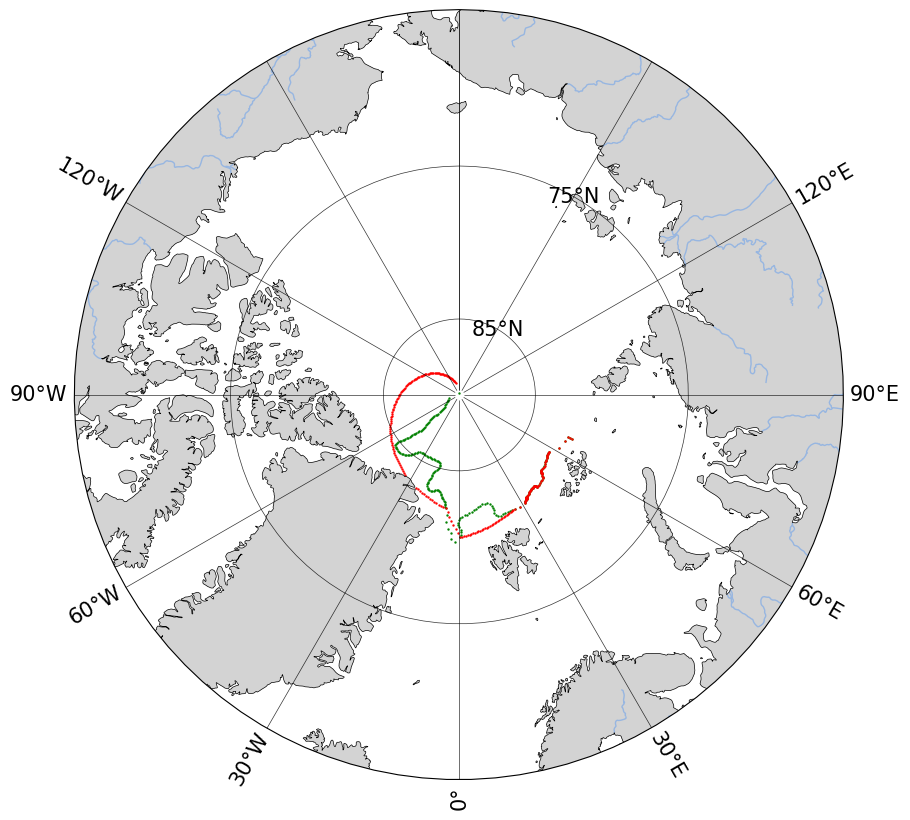

/data0/user/aprigent/ARGO/Arctic/6903119_prof.nc
This file has interpolated position: /data0/user/aprigent/ARGO/Arctic/6903119_prof.nc
TEMP mean =  0.3725868282690891
TEMP min =  -1.848082529714821
psal/temp dimension missmatch
---------
    
/data0/user/aprigent/ARGO/Arctic/6903143_prof.nc
Correcting lon/lat


/tmp/ipykernel_1753263/2069012634.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv('/data0/user/aprigent/ARGO/estimate_profile_locations_' + str(platform_num) + '.csv',


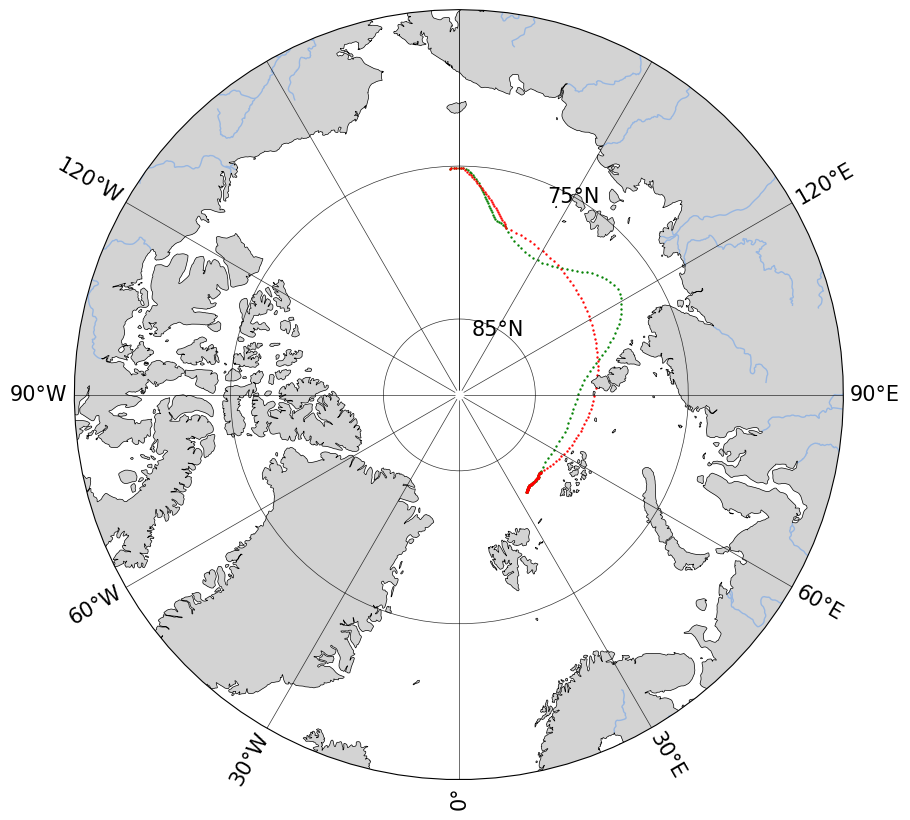

/data0/user/aprigent/ARGO/Arctic/6903143_prof.nc
This file has interpolated position: /data0/user/aprigent/ARGO/Arctic/6903143_prof.nc
TEMP mean =  0.22212947080775794
TEMP min =  -1.863897468362574
---------
    
/data0/user/aprigent/ARGO/Arctic/6903144_prof.nc
Correcting lon/lat


/tmp/ipykernel_1753263/2069012634.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv('/data0/user/aprigent/ARGO/estimate_profile_locations_' + str(platform_num) + '.csv',


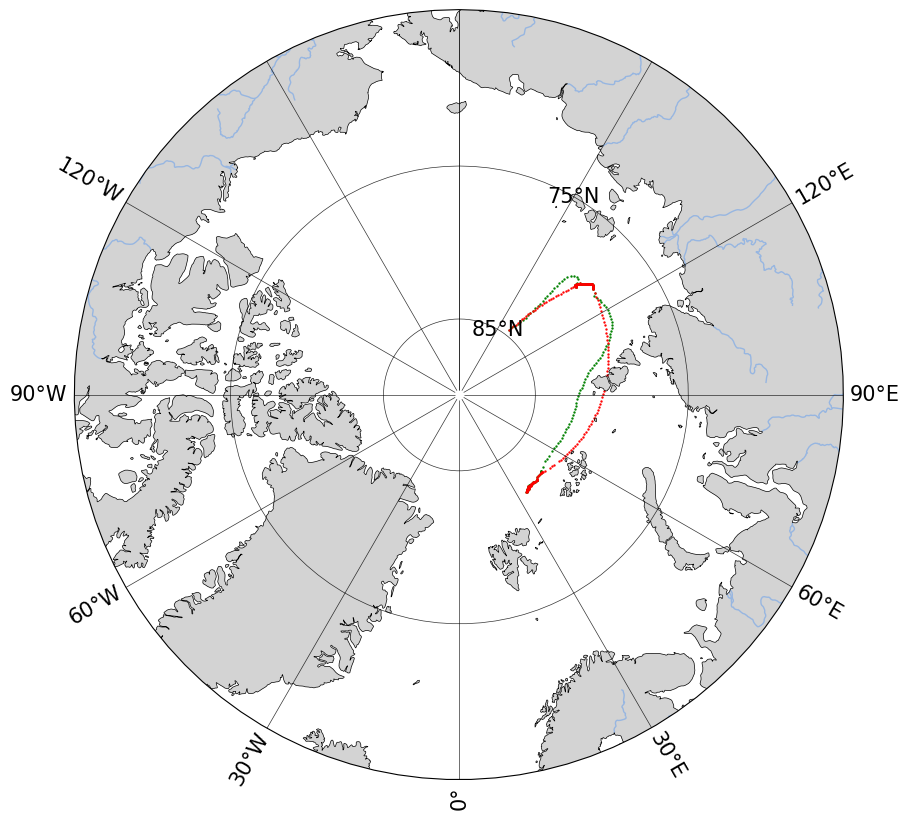

/data0/user/aprigent/ARGO/Arctic/6903144_prof.nc
This file has interpolated position: /data0/user/aprigent/ARGO/Arctic/6903144_prof.nc
TEMP mean =  -0.17279254659378682
TEMP min =  -1.833219473722617
---------
    
/data0/user/aprigent/ARGO/Arctic/6903145_prof.nc
Correcting lon/lat


/tmp/ipykernel_1753263/2069012634.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv('/data0/user/aprigent/ARGO/estimate_profile_locations_' + str(platform_num) + '.csv',


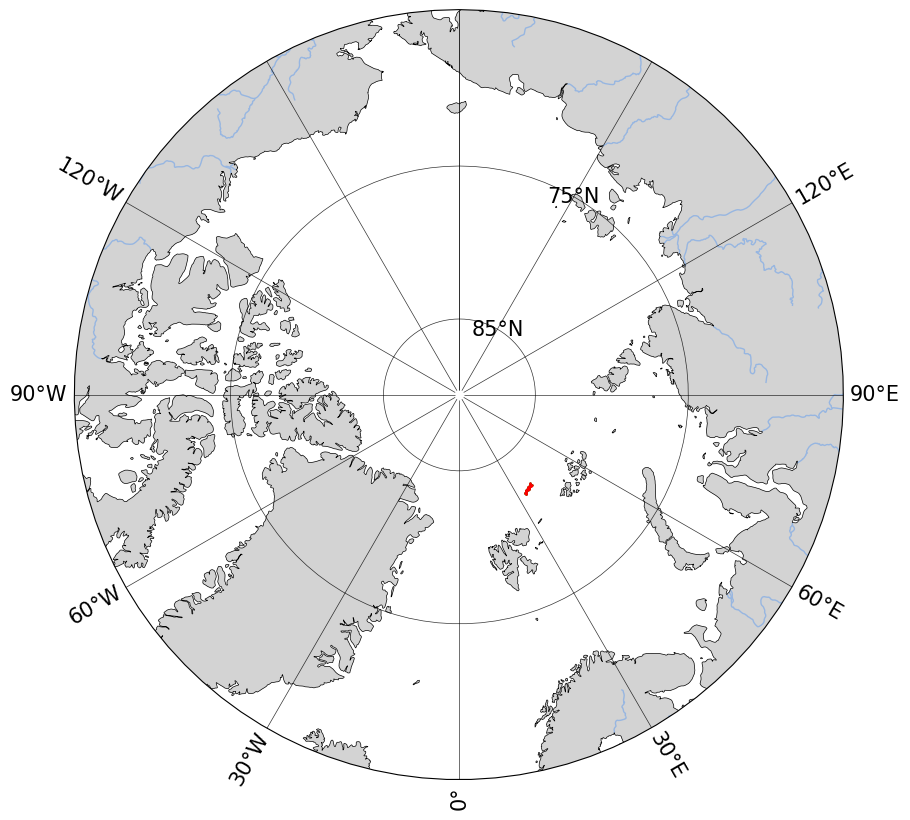

/data0/user/aprigent/ARGO/Arctic/6903145_prof.nc
This file has interpolated position: /data0/user/aprigent/ARGO/Arctic/6903145_prof.nc
---------
    
/data0/user/aprigent/ARGO/Arctic/6903146_prof.nc
Correcting lon/lat


/tmp/ipykernel_1753263/2069012634.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv('/data0/user/aprigent/ARGO/estimate_profile_locations_' + str(platform_num) + '.csv',


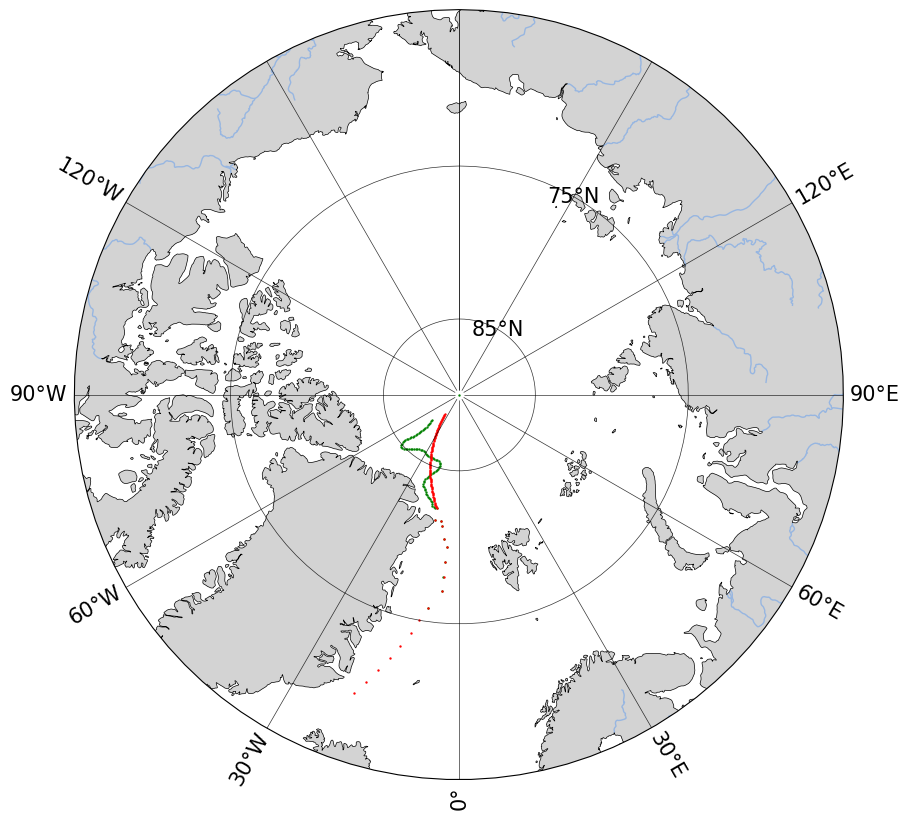

/data0/user/aprigent/ARGO/Arctic/6903146_prof.nc
This file has interpolated position: /data0/user/aprigent/ARGO/Arctic/6903146_prof.nc
TEMP mean =  0.5859565669434943
TEMP min =  -1.827634768585669
---------
    
/data0/user/aprigent/ARGO/Arctic/6903147_prof.nc
Correcting lon/lat


/tmp/ipykernel_1753263/2069012634.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv('/data0/user/aprigent/ARGO/estimate_profile_locations_' + str(platform_num) + '.csv',


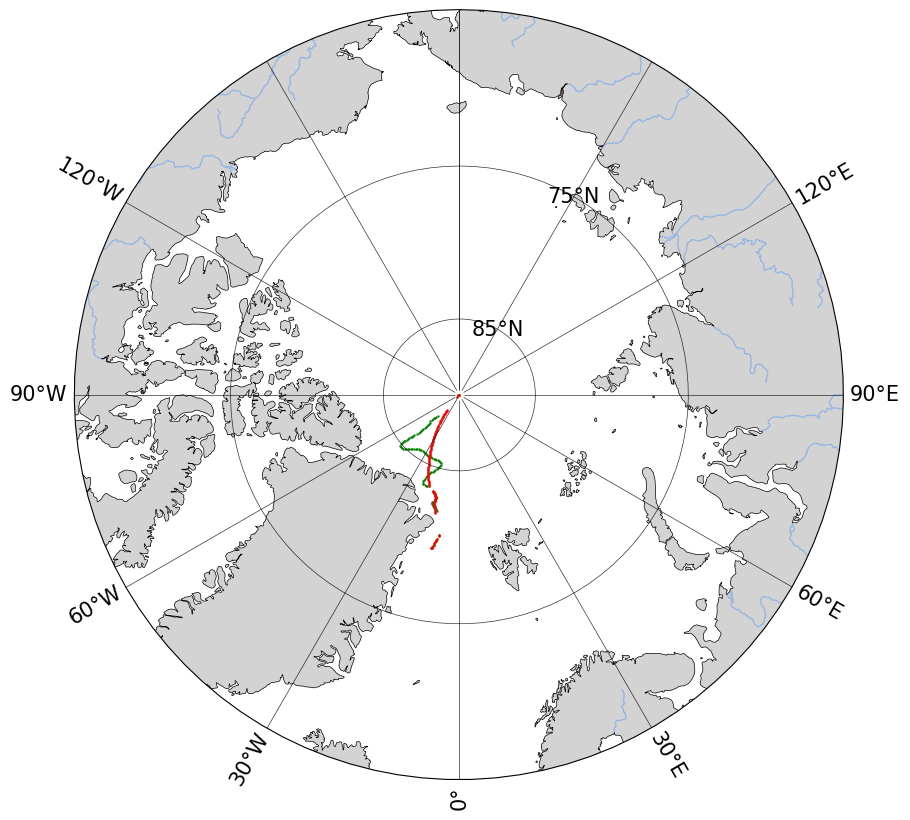

/data0/user/aprigent/ARGO/Arctic/6903147_prof.nc
This file has interpolated position: /data0/user/aprigent/ARGO/Arctic/6903147_prof.nc
TEMP mean =  -0.05452184952138985
TEMP min =  -1.7910000085830688
---------
    
/data0/user/aprigent/ARGO/Arctic/7901038_prof.nc
Correcting lon/lat


/tmp/ipykernel_1753263/2069012634.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv('/data0/user/aprigent/ARGO/estimate_profile_locations_' + str(platform_num) + '.csv',


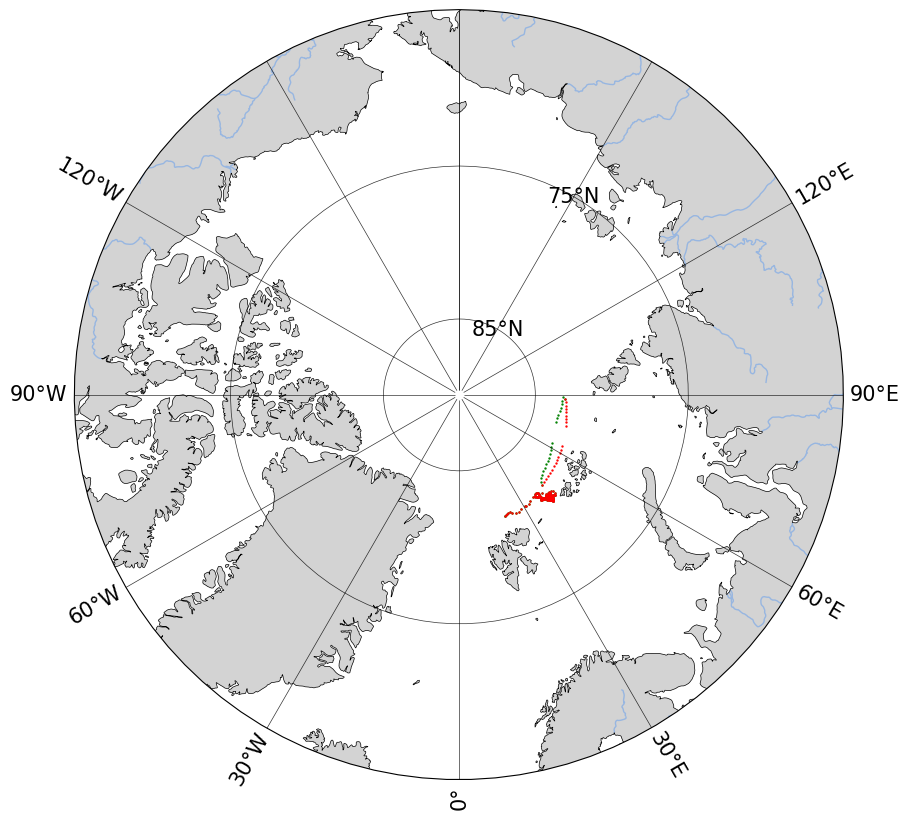

/data0/user/aprigent/ARGO/Arctic/7901038_prof.nc
This file has interpolated position: /data0/user/aprigent/ARGO/Arctic/7901038_prof.nc
TEMP mean =  0.4560193862347216
TEMP min =  -1.871000051498413
---------
    
/data0/user/aprigent/ARGO/Arctic/3902112_prof.nc
Correcting lon/lat


/tmp/ipykernel_1753263/2069012634.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv('/data0/user/aprigent/ARGO/estimate_profile_locations_' + str(platform_num) + '.csv',


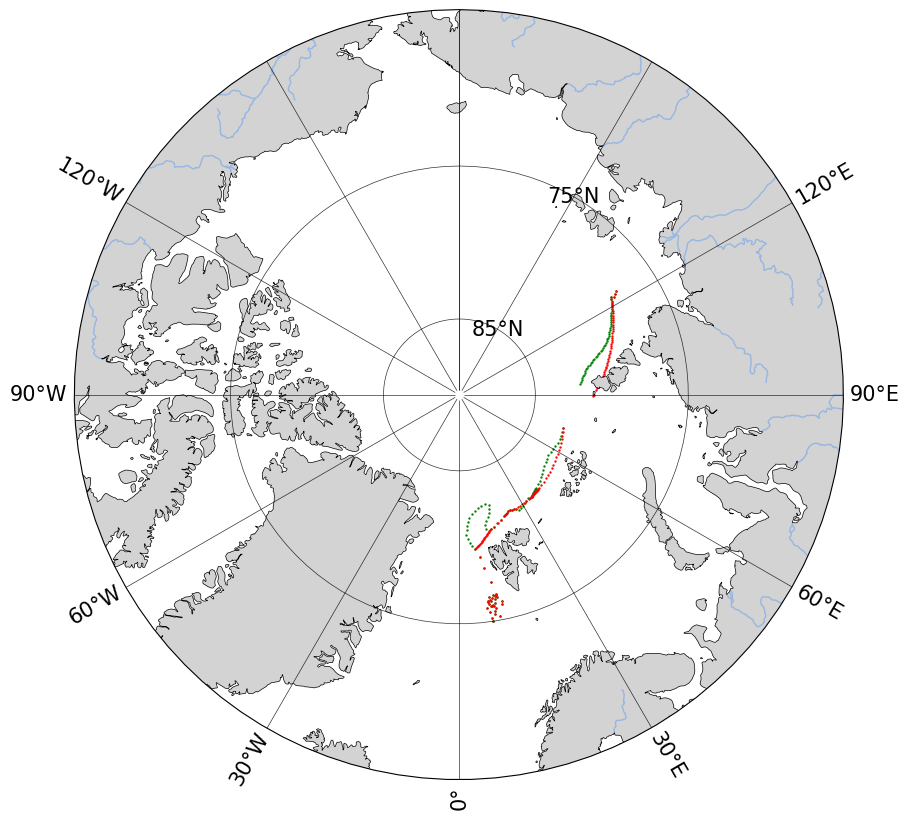

/data0/user/aprigent/ARGO/Arctic/3902112_prof.nc
This file has interpolated position: /data0/user/aprigent/ARGO/Arctic/3902112_prof.nc
TEMP mean =  0.5556370021261335
TEMP min =  -1.8761451478638442
---------
    
/data0/user/aprigent/ARGO/Arctic/3902118_prof.nc
Correcting lon/lat


/tmp/ipykernel_1753263/2069012634.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv('/data0/user/aprigent/ARGO/estimate_profile_locations_' + str(platform_num) + '.csv',


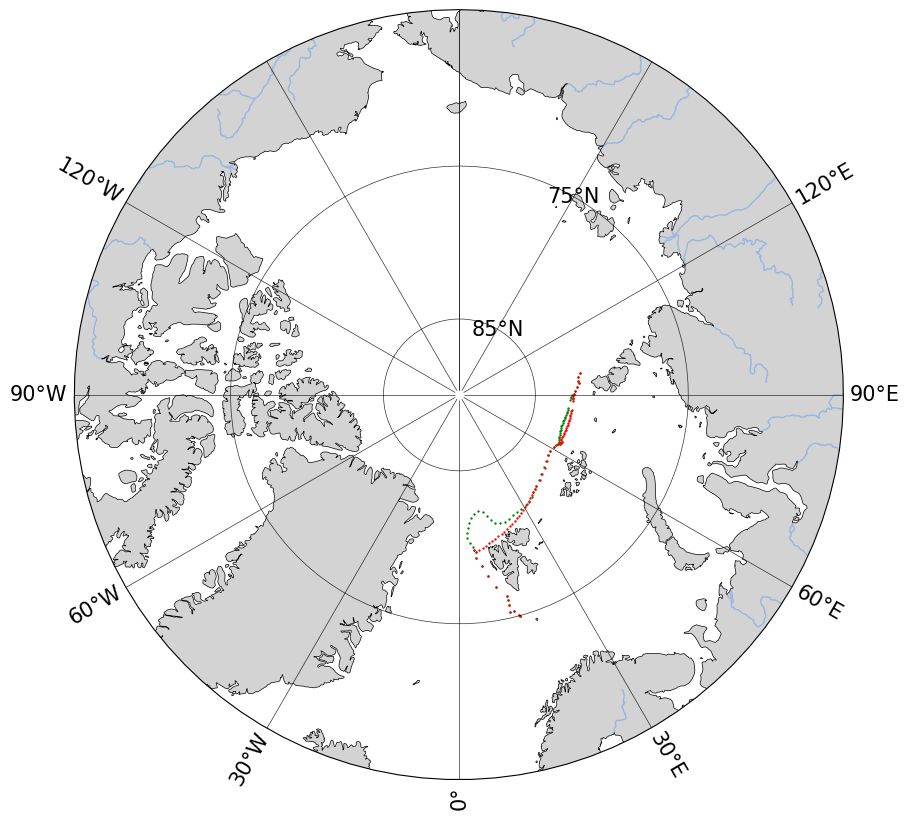

/data0/user/aprigent/ARGO/Arctic/3902118_prof.nc
This file has interpolated position: /data0/user/aprigent/ARGO/Arctic/3902118_prof.nc
TEMP mean =  0.841173762079852
TEMP min =  -1.8650000095367432
---------
    
/data0/user/aprigent/ARGO/Arctic/4903655_prof.nc
Correcting lon/lat


/tmp/ipykernel_1753263/2069012634.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv('/data0/user/aprigent/ARGO/estimate_profile_locations_' + str(platform_num) + '.csv',


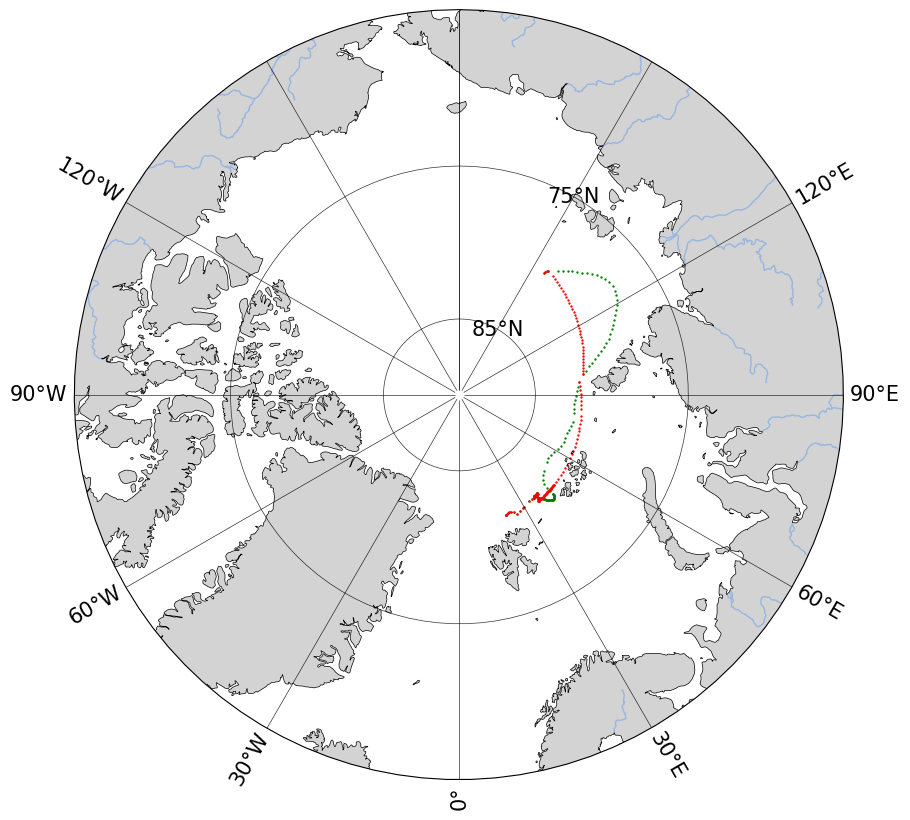

/data0/user/aprigent/ARGO/Arctic/4903655_prof.nc
This file has interpolated position: /data0/user/aprigent/ARGO/Arctic/4903655_prof.nc
TEMP mean =  0.564785227713998
TEMP min =  -1.8589999675750732
---------
    
/data0/user/aprigent/ARGO/Arctic/6903587_prof.nc
Correcting lon/lat


/tmp/ipykernel_1753263/2069012634.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv('/data0/user/aprigent/ARGO/estimate_profile_locations_' + str(platform_num) + '.csv',


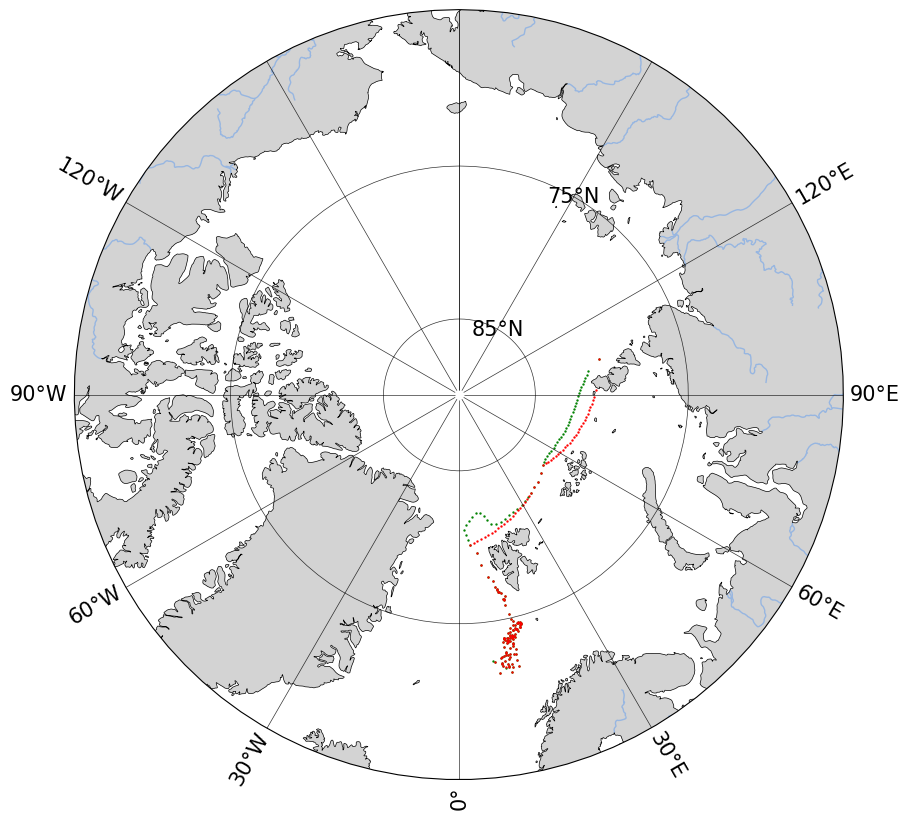

/data0/user/aprigent/ARGO/Arctic/6903587_prof.nc
This file has interpolated position: /data0/user/aprigent/ARGO/Arctic/6903587_prof.nc
TEMP mean =  1.3757197067613256
TEMP min =  -1.8617358047388533
---------
    
/data0/user/aprigent/ARGO/Arctic/6903588_prof.nc
Correcting lon/lat


/tmp/ipykernel_1753263/2069012634.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv('/data0/user/aprigent/ARGO/estimate_profile_locations_' + str(platform_num) + '.csv',


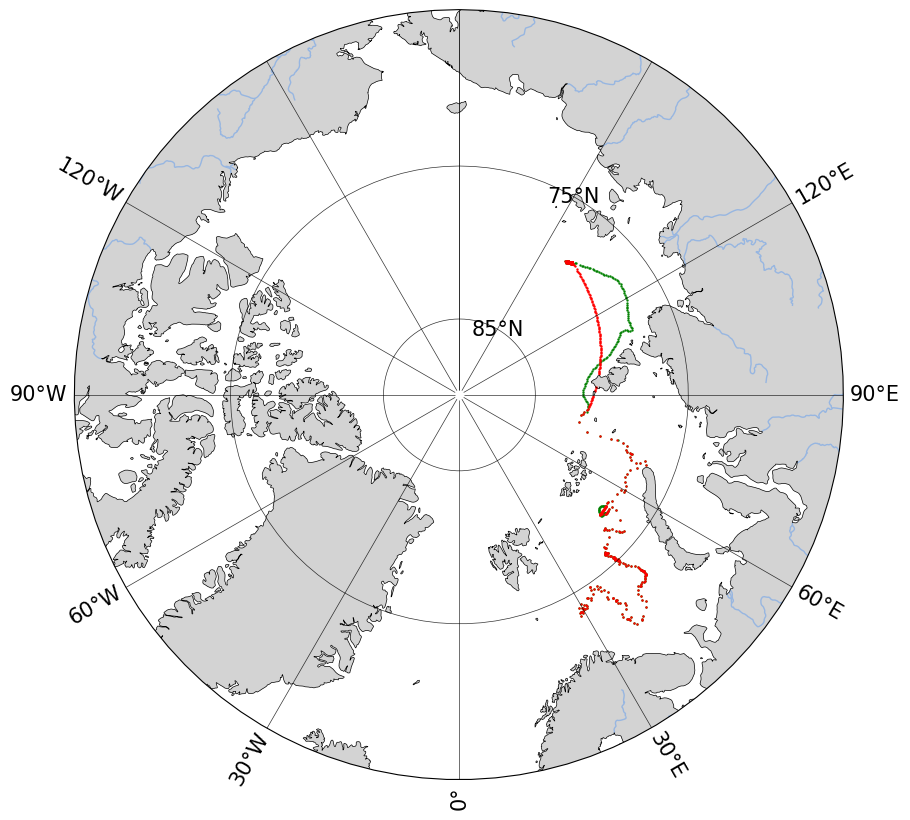

/data0/user/aprigent/ARGO/Arctic/6903588_prof.nc
This file has interpolated position: /data0/user/aprigent/ARGO/Arctic/6903588_prof.nc
TEMP mean =  0.5092509942982706
TEMP min =  -1.8508407625320713
psal/temp dimension missmatch
---------
    
/data0/user/aprigent/ARGO/Arctic/6903589_prof.nc
Correcting lon/lat


/tmp/ipykernel_1753263/2069012634.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv('/data0/user/aprigent/ARGO/estimate_profile_locations_' + str(platform_num) + '.csv',


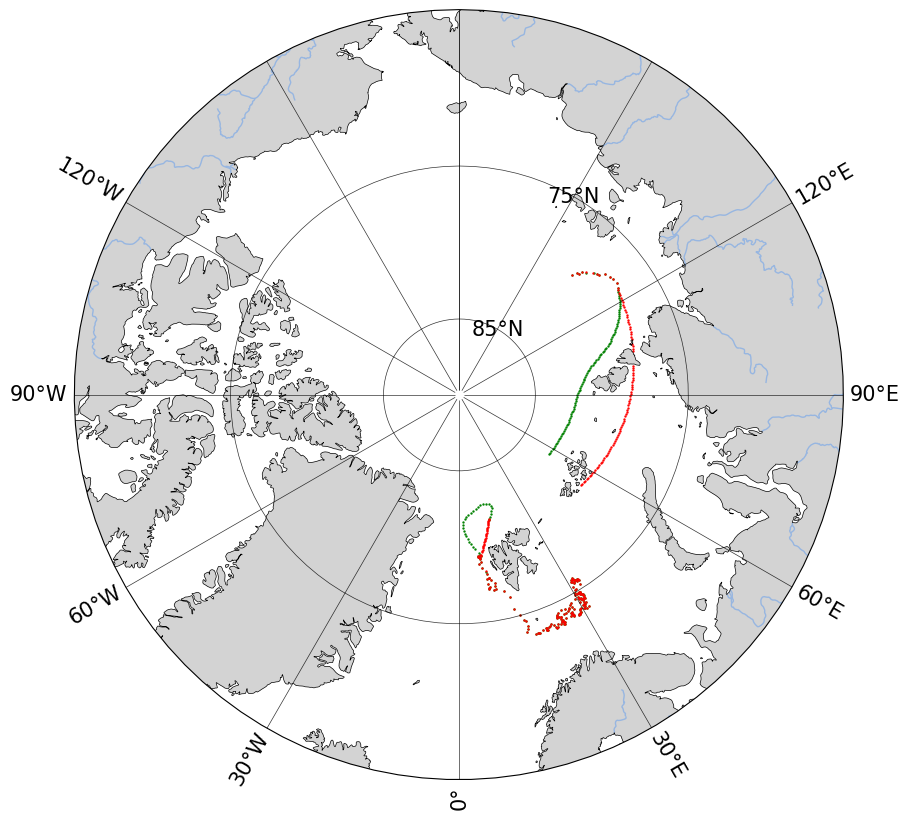

/data0/user/aprigent/ARGO/Arctic/6903589_prof.nc
This file has interpolated position: /data0/user/aprigent/ARGO/Arctic/6903589_prof.nc
TEMP mean =  1.400588277403997
TEMP min =  -1.8669999837875366
psal/temp dimension missmatch
---------
    
/data0/user/aprigent/ARGO/Arctic/6904087_prof.nc
Correcting lon/lat


/tmp/ipykernel_1753263/2069012634.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv('/data0/user/aprigent/ARGO/estimate_profile_locations_' + str(platform_num) + '.csv',


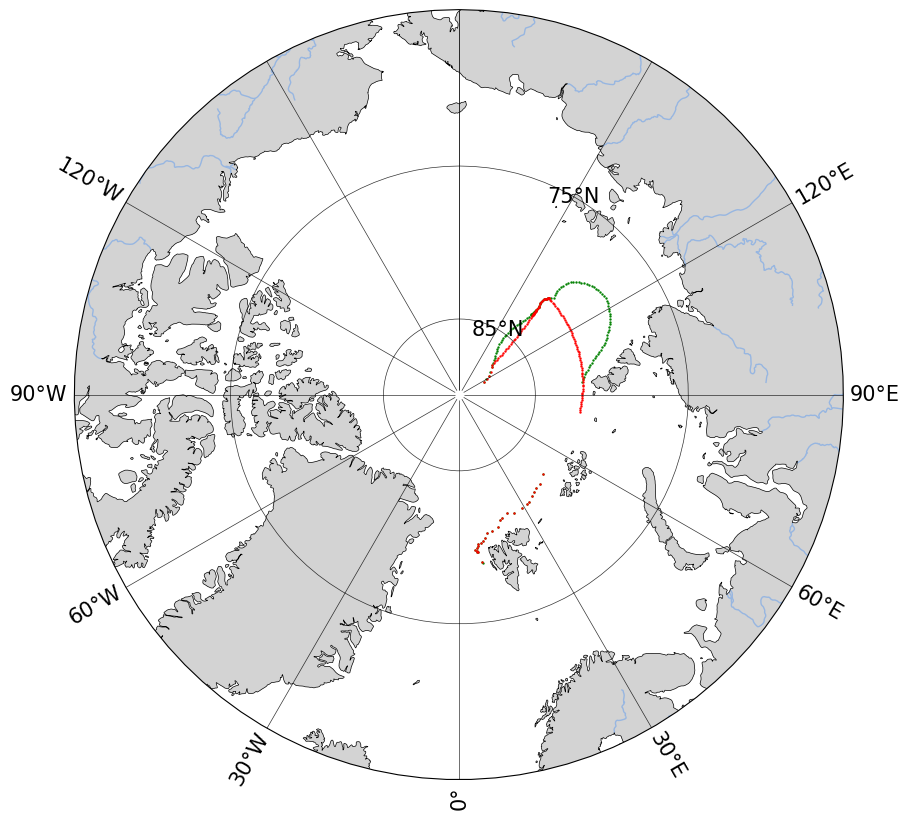

/data0/user/aprigent/ARGO/Arctic/6904087_prof.nc
This file has interpolated position: /data0/user/aprigent/ARGO/Arctic/6904087_prof.nc
TEMP mean =  0.11722875700485876
TEMP min =  -1.8370000123977661
---------
    
/data0/user/aprigent/ARGO/Arctic/7900549_prof.nc
Correcting lon/lat


/tmp/ipykernel_1753263/2069012634.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv('/data0/user/aprigent/ARGO/estimate_profile_locations_' + str(platform_num) + '.csv',


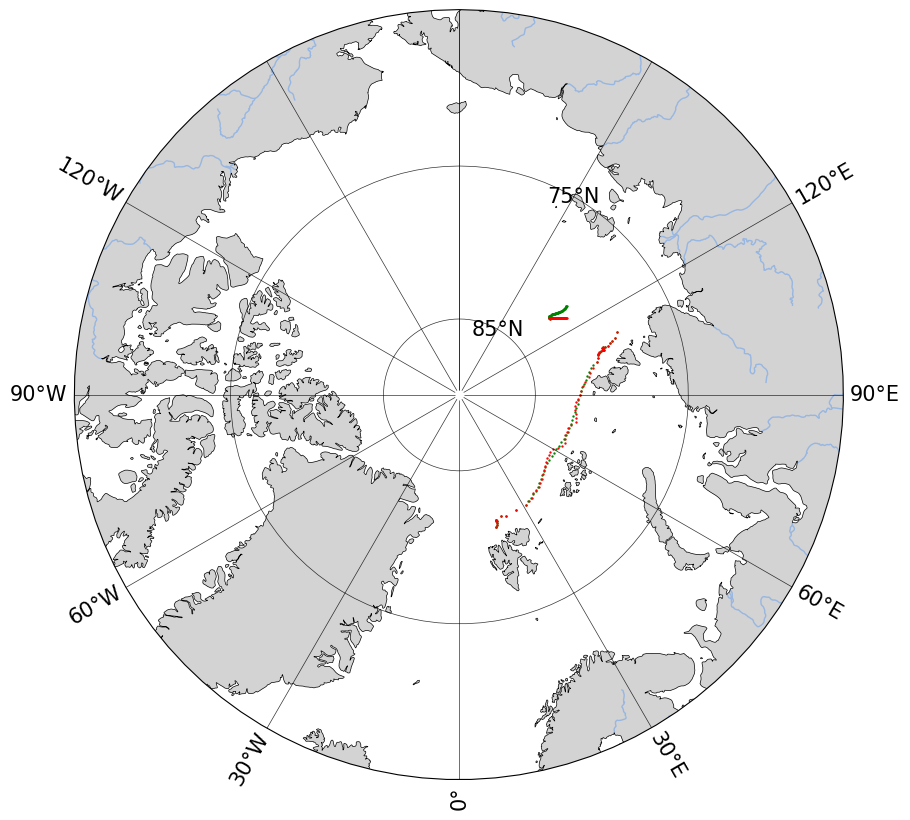

/data0/user/aprigent/ARGO/Arctic/7900549_prof.nc
This file has interpolated position: /data0/user/aprigent/ARGO/Arctic/7900549_prof.nc
TEMP mean =  0.25590292374241974
TEMP min =  -1.8720512115306218
---------
    
/data0/user/aprigent/ARGO/Arctic/7902188_prof.nc
Correcting lon/lat


/tmp/ipykernel_1753263/2069012634.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv('/data0/user/aprigent/ARGO/estimate_profile_locations_' + str(platform_num) + '.csv',


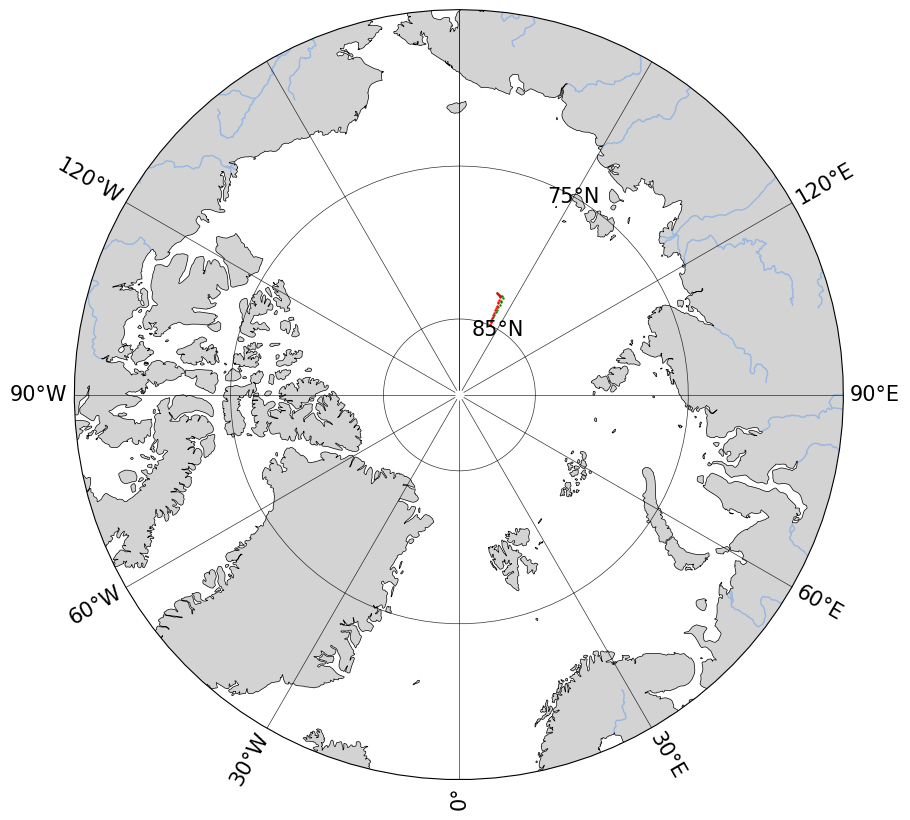

/data0/user/aprigent/ARGO/Arctic/7902188_prof.nc
This file has interpolated position: /data0/user/aprigent/ARGO/Arctic/7902188_prof.nc
TEMP mean =  -0.07440342903898603
TEMP min =  -1.8380000591278076
psal/temp dimension missmatch


In [7]:

data_out = '/data0/user/aprigent/ARGO/Arctic/'

n_qc8 = []
n_prof = []
interpolated_position_file = []
nb_temp_prof_init = 0
nb_psal_prof_init = 0

nb_temp_prof_qc_interp = 0
nb_psal_prof_qc_interp = 0
ref_time = dt.datetime(1950,1,1).toordinal()
for f in list_file:
    print('---------')
    
    print('    ')
    print(f)
    itp = xr.open_dataset(f,decode_times=False)
    # print(itp)
    platform_num = int(itp.PLATFORM_NUMBER[0].values)

    if platform_num in [6903119, 6903143,6903144,6903145,6903146,
                                  6903147,7901038,3902112,3902118,4903655,
                                  6903587,6903588,6903589,6904087,7900549,7902188]: # csv file at /data0/user/aprigent/ARGO
        print('Correcting lon/lat')
        df = pd.read_csv('/data0/user/aprigent/ARGO/estimate_profile_locations_' + str(platform_num) + '.csv',
                         sep=";", index_col=False)
        ds_traj = xr.Dataset.from_dataframe(df)

        # Replace Argo lon/lat with corrected trajectory values
        cycle = ds_traj.CyNum.values
        lon_corr = ds_traj.Lon.values
        lat_corr = ds_traj.Lat.values
        plot_trajectories(lon_corr,lat_corr,itp.LONGITUDE.values,itp.LATITUDE.values)
        
        # Only update cycles where both lon and lat are valid (not NaN)
        for c, lo, la in zip(cycle, lon_corr, lat_corr):
            if np.isnan(lo) or np.isnan(la):
                print(f"Skipping cycle {c}: missing lon/lat")
                continue
            mask = itp["CYCLE_NUMBER"] == c
            itp["LONGITUDE"] = xr.where(mask, lo, itp["LONGITUDE"])
            itp["LATITUDE"] = xr.where(mask, la, itp["LATITUDE"])
            

    
    # --- TIME QC CHECK ---
    juld_qc = itp.JULD_QC.data
    qc_time = juld_qc == b'1'

    juld_ord = np.array([int(ref_time + t) for t in itp.JULD.data[qc_time]])

    if len(juld_ord) == 0:
        print('No QC time')
        continue
    
    if juld_ord[-1]> dt.datetime(1999,12,31).toordinal():
        
        print(f)
        pres = itp.PRES_ADJUSTED.data[qc_time]
        lat = itp.LATITUDE.data[qc_time]
        lon = itp.LONGITUDE.data[qc_time]
        psal= itp.PSAL_ADJUSTED.data[qc_time]
        temp=itp.TEMP_ADJUSTED.data[qc_time]
        nb_temp_prof_init += temp.shape[0]
        nb_psal_prof_init += psal.shape[0]
        psal_qc = itp.PSAL_ADJUSTED_QC.data[qc_time]
        temp_qc = itp.TEMP_ADJUSTED_QC.data[qc_time]
        data_mode = itp.DATA_MODE.data[qc_time]
        press_qc = itp.PRES_ADJUSTED_QC.data[qc_time]
        pos_qc = itp.POSITION_QC.data[qc_time]
        platform_id = np.array([int(p.decode().strip()) for p in itp.PLATFORM_NUMBER.values])
        platform_id = platform_id[qc_time]
        qc_press = press_qc == b'1'
        pres[~qc_press] = np.nan
        dep = -gsw.z_from_p(pres.T,lat).T
        
        
        
        qc1_pos = (pos_qc == b'1')|(pos_qc == b'8')
        
        if (pos_qc == b'8').any():
            print('This file has interpolated position:', f)
            interpolated_position_file.append(f)
            n_qc8.append((pos_qc == b'8').sum())
            n_prof.append(itp.N_PROF.shape[0])
        
        qc1_psal = psal_qc == b'1'
        qc1_temp = temp_qc == b'1'
        qc_mode = (data_mode == b'D') | (data_mode == b'A') | (data_mode == b'r')

        qc_mode_2d_psal = np.broadcast_to(qc_mode[:, None], psal.shape)
        qc_mode_2d_temp = np.broadcast_to(qc_mode[:, None], temp.shape)
        qc_pos_2d_psal = np.broadcast_to(qc1_pos[:, None], psal.shape)
        qc_pos_2d_temp = np.broadcast_to(qc1_pos[:, None], temp.shape)
        
        final_mask_temp = ~(qc_pos_2d_temp & qc1_temp & qc_press & qc_mode_2d_temp)
        final_mask_psal = ~(qc_pos_2d_psal & qc1_psal & qc_press & qc_mode_2d_psal)

        
        psal[final_mask_psal] = np.nan
        temp[final_mask_temp] = np.nan     
        
        
        n_levels_temp = np.ones((dep.shape[0]))*dep.shape[1]
        n_levels_psal  = np.ones((dep.shape[0]))*dep.shape[1]
        
        sum_temp = np.nansum(temp,axis=1)
        sum_psal  = np.nansum(psal,axis=1)
        sum_dep = np.nansum(dep,axis=1)



        
        
        
        PSAL,ipsal = interp_prof(dep,psal,zi)
        TEMP,itemp = interp_prof(dep,temp,zi)

        TEMP[TEMP<-2] = np.nan
        TEMP[TEMP>30] = np.nan
        PSAL[PSAL<0] = np.nan
        PSAL[PSAL>40] = np.nan
        if len(itemp)!=0:
            print('TEMP mean = ',np.nanmean(TEMP))
            print('TEMP min = ',np.nanmin(TEMP))
            TIMEt = np.array(juld_ord)[itemp]
            LONt = lon[itemp]
            LATt = lat[itemp]
            sum_TEMP = sum_temp[itemp]
            n_levels_TEMP = n_levels_temp[itemp]
            sum_dep_TEMP = sum_dep[itemp]
            platform_TEMP = platform_id[itemp]
        
        nb_temp_prof_qc_interp += TEMP.shape[0]
        nb_psal_prof_qc_interp += PSAL.shape[0]
        
        if len(ipsal) != len(itemp):
            print('psal/temp dimension missmatch')
        if len(ipsal)!=0:
            TIMEs = np.array(juld_ord)[ipsal]
            LONs = lon[ipsal]
            LATs = lat[ipsal]
            sum_PSAL  = sum_psal[ipsal]
            n_levels_PSAL = n_levels_psal[ipsal]
            sum_dep_PSAL = sum_dep[ipsal]
            platform_PSAL = platform_id[ipsal]
        
            # save file PSAL
            ds = xr.Dataset({'latitude': (['prof'], LATs),
                             'longitude': (['prof'], LONs),
                             'time': (['prof'], TIMEs),
                             'salinity': (['prof','levels'], PSAL),
                             'platform_id': (['prof'], platform_PSAL),
                             'sum_salinity': (['prof'], sum_PSAL),
                             'sum_levels': (['prof'], sum_dep_PSAL),
                             'nb_levels': (['prof'], n_levels_PSAL),
                             'depth': (['levels'], zi)},
                            coords={'prof': (['prof'], np.arange(0,len(TIMEs))), 'levels':(['levels'], zi)})
            
            # global attributes
            ds.attrs['Comments'] = 'Argo float salinity profiles (data mode=D) interpolated on ISAS vertical levels using a Akima 1D interpolator scheme (scipy)'
            ds.attrs['Original file'] = f[33:]
            ds.attrs['title'] = 'Argo salinity profiles on ISAS vertical grid'
            ds.attrs['source'] = 'Argo'
            ds.attrs['history'] = 'Created with xarray'
            
            # variable attributes
            ds['latitude'].attrs = {'long_name':'Latitude','units':'degrees_north','standard_name':'latitude'}
            ds['longitude'].attrs = {'long_name':'Longitude','units':'degrees_east','standard_name':'longitude'}
            ds['time'].attrs = {'long_name':'Time', "units": "days since 0001-01-01 (Python datetime system)"}
            ds['salinity'].attrs = {'long_name':'Salinity (S78 - PSS)',
                                    'units':'1e-3',   # or 'psu'
                                    'standard_name':'sea_water_practical_salinity'}
            ds['depth'].attrs = {'long_name':'Depth','units':'m','positive':'down','standard_name':'depth'}
            ds['platform_id'].attrs = {'long_name':'Argo platform identifier'}
    
    
            ds.to_netcdf(data_out + f[33:-3] + '_ISAS_PSAL.nc')   
            
            # save file TEMP
            ds = xr.Dataset({'latitude': (['prof'], LATt),
                             'longitude': (['prof'], LONt),
                             'time': (['prof'], TIMEt),
                             'temperature': (['prof','levels'], TEMP),
                             'platform_id': (['prof'], platform_TEMP),
                             'sum_temperature': (['prof'], sum_TEMP),
                             'sum_levels': (['prof'], sum_dep_TEMP),
                             'nb_levels': (['prof'], n_levels_TEMP),
                             'depth': (['levels'], zi)},
                            coords={'prof': (['prof'], np.arange(0,len(TIMEt))), 'levels':(['levels'], zi)})
    
            # global attributes
            ds.attrs['Comments'] = 'Argo float temperature profiles (data mode=D) interpolated on ISAS vertical using a Akima 1D interpolator scheme (scipy)'
            ds.attrs['Original file'] = f[33:]
            ds.attrs['title'] = 'Argo temperature profiles on ISAS vertical grid'
            ds.attrs['source'] = 'Argo'
            ds.attrs['history'] = 'Created with xarray'
            ds['platform_id'].attrs = {'long_name':'Argo platform identifier'}
            
            # variable attributes
            ds['latitude'].attrs = {'long_name':'Latitude','units':'degrees_north','standard_name':'latitude'}
            ds['longitude'].attrs = {'long_name':'Longitude','units':'degrees_east','standard_name':'longitude'}
            ds['time'].attrs = {'long_name':'Time', "units": "days since 0001-01-01 (Python datetime system)"}
            ds['temperature'].attrs = {'long_name':'Temperature (T90)',
                                       'units':'degree_Celsius',
                                       'standard_name':'sea_water_temperature'}
            ds['depth'].attrs = {'long_name':'Depth','units':'m','positive':'down','standard_name':'depth'}
    

    
            ds.to_netcdf(data_out + f[33:-3] + '_ISAS_TEMP.nc')         

In [8]:
import pandas as pd

table = pd.DataFrame({
    "interpolated_position_file": interpolated_position_file,
    "n_qc8": n_qc8,
    "n_prof": n_prof,
    "ratio": np.round(np.array(n_qc8)/np.array(n_prof)*100,2)
    
})


# table = table.sort_values("n_qc8", ascending=False)
# table.to_csv(
#     "qc8_table_argo_65N.csv",
#     index=False,
#     float_format="%.4f",    # lon/lat readable, not 1.23456789e+01
#     sep=";",                # semicolon → Excel (French locale) opens cleanly
#     encoding="utf-8-sig",   # BOM header → Excel detects UTF-8 without garbling
# )

In [9]:
# table = pd.read_csv('qc8_table_argo_65N.csv')

In [10]:
idx = np.argsort(n_qc8)

interpolated_position_file_sorted = np.array(interpolated_position_file)[idx]
n_qc8_sorted = np.array(n_qc8)[idx]

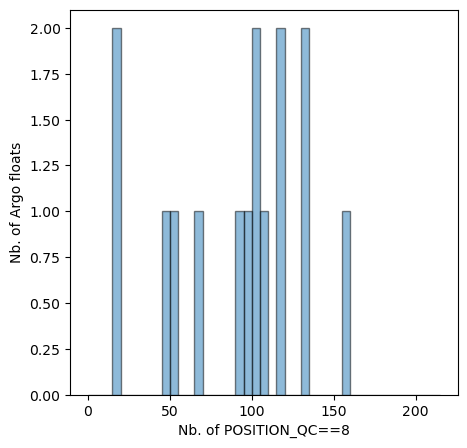

In [11]:
f,ax = plt.subplots(1,1,figsize=[5,5])
ax.hist(n_qc8_sorted,bins=np.arange(0,220,5),edgecolor='black',alpha=0.5,)
ax.set_xlabel('Nb. of POSITION_QC==8')
ax.set_ylabel('Nb. of Argo floats')

plt.savefig(f'/home/aprigent/Documents/Projects/Analysis_obs/figures/distribution_qc8_argo_above_65N.png',
            bbox_inches='tight',dpi=300)

In [12]:
table['interpolated_position_file'][0]

'/data0/user/aprigent/ARGO/Arctic/6903119_prof.nc'

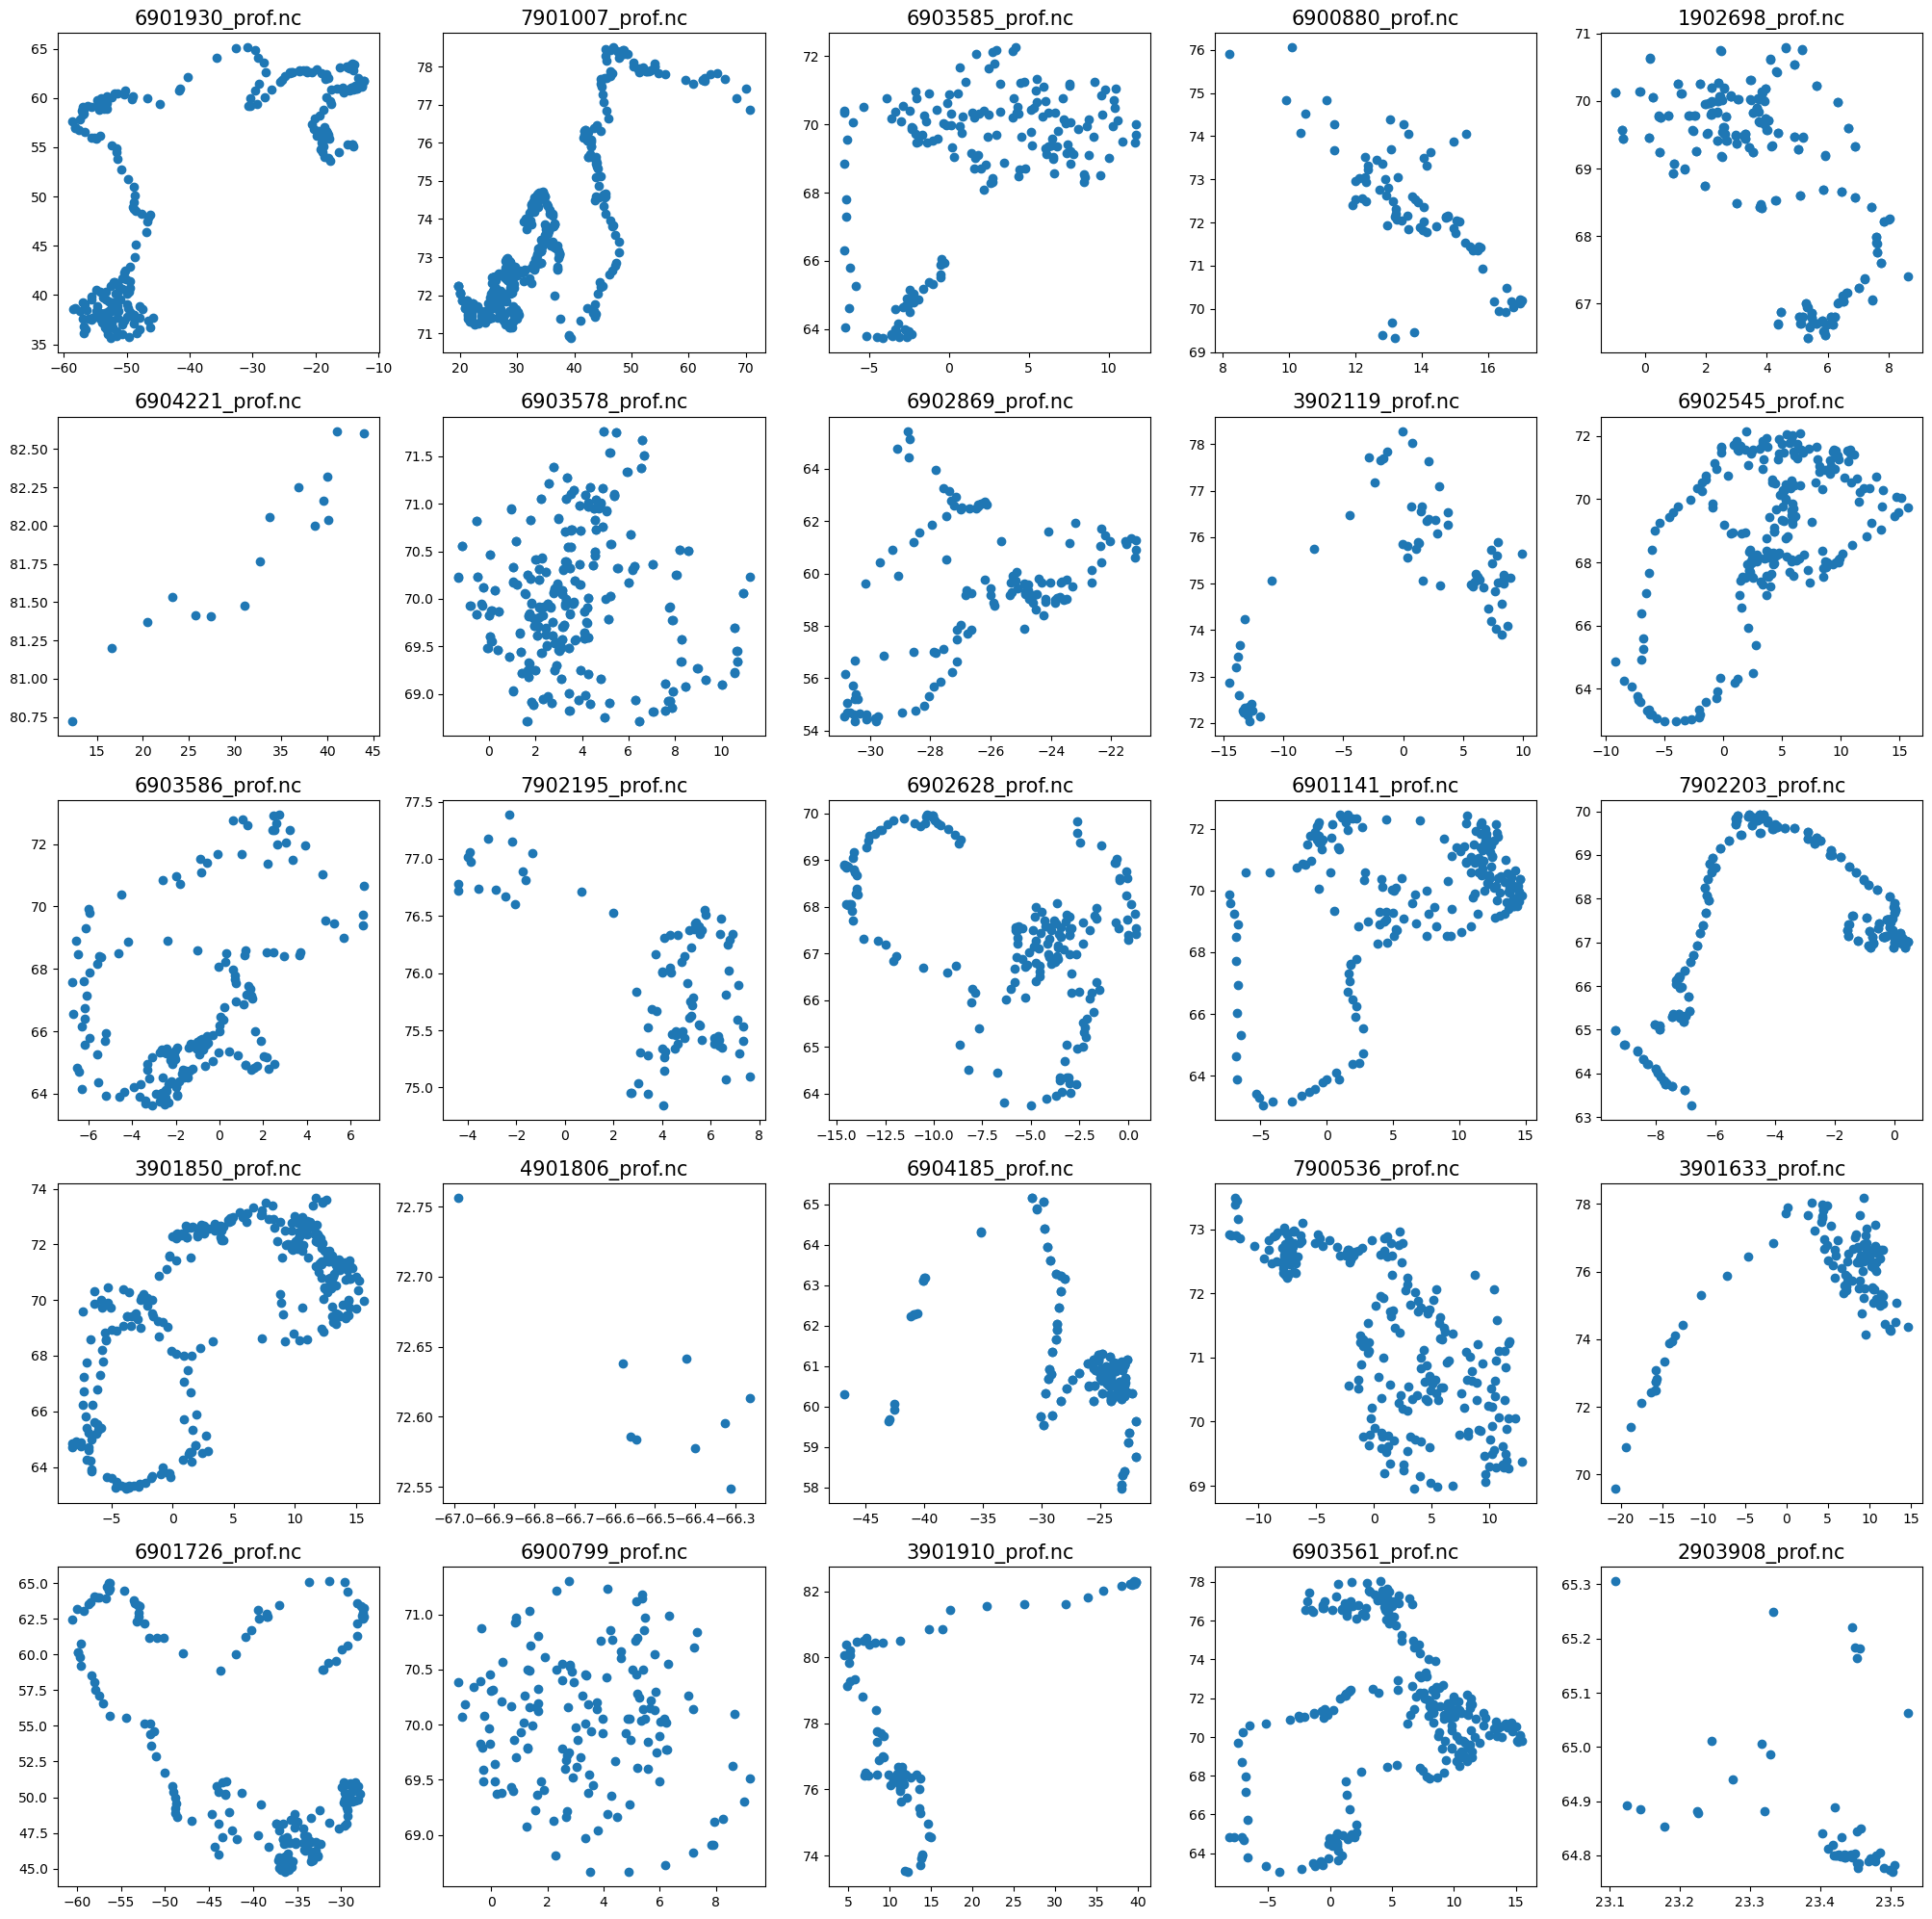

In [155]:
f,ax = plt.subplots(5,5,figsize=[25,25])
ax=ax.ravel()

id_argo_range = np.arange(0,25,1)
for i in range(id_argo_range.shape[0]):
    test = xr.open_dataset(interpolated_position_file_sorted[id_argo_range[i]])

    ax[i].scatter(test.LONGITUDE,test.LATITUDE)
    ax[i].set_title(interpolated_position_file_sorted[id_argo_range[i]][-15:],fontsize=ftz)
    
    
plt.savefig(f'/home/aprigent/Documents/Projects/Analysis_obs/figures/fig_argo_needing_trajectory_correction_bottom25.png',
            bbox_inches='tight',dpi=300)

In [13]:

argo_path = '/data0/user/aprigent/ARGO/Arctic/'
argo_list_psal = glob.glob(argo_path + '*ISAS_PSAL.nc')
argo_list_temp = glob.glob(argo_path + '*ISAS_TEMP.nc')

ds_argo_psal_test = Atools.create_merged_dataset_psal_itp(argo_list_psal,'ARGO','psal')
ds_argo_temp_test = Atools.create_merged_dataset_temp_itp(argo_list_temp,'ARGO','temp')

Text(0.5, 1.0, 'ARGO')

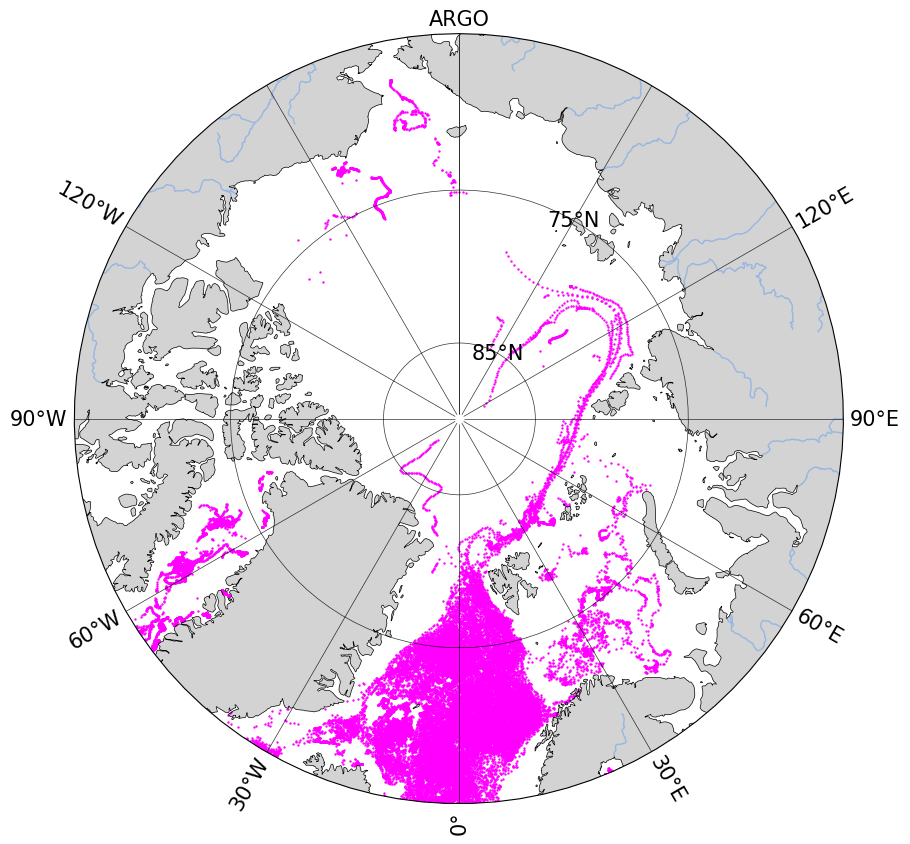

In [14]:


f,ax = plt.subplots(1,1,figsize=[15,10],subplot_kw={'projection': ccrs.NorthPolarStereo()})
ftz=15


Atools.plot_arctic_ax_map_new(ax)
ax.scatter(ds_argo_psal_test.longitude,
           ds_argo_psal_test.latitude,
           marker='.',transform=ccrs.PlateCarree(),s=2,color='magenta',label='All',alpha=1)
ax.set_title('ARGO',fontsize=ftz)
